# PR plots for the de novo models and rescoring methods

In [1]:
import os

from denovo_utils.data import Run
from denovo_utils.parsers import DenovoEngineConverter
from denovo_utils.io.read import load_psmlist

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from denovo_utils.analysis.metrics import load_seq_score_dicts
from denovo_utils.analysis.metrics import get_match_score_table

from psm_utils import Peptidoform
from tqdm import tqdm
from peak_pack.utils import calculate_ppm

from denovo_utils.analysis.metrics import (
    get_refinement_error_tables,
    plot_refinement_error_table,
    plot_precision_recall_refinement,
)

import pandas as pd

from pathlib import Path

from denovo_utils.io.read import read_partitions_features, read_partitions_psmlist
from denovo_utils.io.save import save_psmlist

from glob import glob

from denovo_utils.analysis.metrics import create_refinement_alluvial
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm
import os
from pathlib import Path
import numpy as np
from itertools import chain

2026-09-09 09:08:07.811906: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modification already exists in ModificationsDB. Skipping.


In [7]:
denovo_names = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'InstaNovo',
    'NovoB',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]

In [3]:
def calculate_prc(
        n_correct,
        n_selected,
        n_predicted
):
    c = n_correct
    ci = n_selected
    u = n_predicted - ci

    # precision
    precision = c/ci

    # recall (This is an alternative definition and the line will stop at x=y)
    recall = c/n_predicted

    # coverage
    coverage = ci/n_predicted

    return precision, recall, coverage


def get_prc_curve(t, n_predicted = None):
    prs = []
    recs = []
    covs = []

    t = t.sort_values('score', ascending=False).reset_index(drop=True)

    if n_predicted is None:
        n_predicted = len(t)

    for coverage in tqdm(np.linspace(0,1,200)):
        if coverage == 0:
            continue
        n_samples = coverage * len(t)
        samples_evaluated = t[t.index<n_samples]
        
        pr, rec, cov = calculate_prc(
            n_correct=len(samples_evaluated[samples_evaluated.match]),
            n_selected=len(samples_evaluated),
            n_predicted=n_predicted,
        )
        prs.append(pr)
        recs.append(rec)
        covs.append(cov)

    return pd.DataFrame(
        {'precision': prs,
         'recall': recs,
         'coverage': covs}
    )

def assign_colors(row, base_engine, post_processor):
    # Good refinements
    if (row[f'{base_engine}'] == 'Correct') & (row[f'{post_processor}'] == 'Correct'):
        return 'grey'
    if (row[f'{base_engine}'] != 'Correct') & (row[f'{post_processor}'] == 'Correct'):
        return 'mediumseagreen'

    # Medium refinement
    if (row[f'{base_engine}'] == 'Incorrect - Not in FASTA') & (row[f'{post_processor}'] == 'Incorrect - In FASTA'):
        return 'orange'

    # Bad refinement
    if (row[f'{base_engine}'] == 'Correct') & (row[f'{post_processor}'] != 'Correct'):
        return px.colors.qualitative.Prism[7]
    
    # No improvement cases
    if (row[f'{base_engine}'] == 'Incorrect - In FASTA') & (row[f'{post_processor}'] == 'Incorrect - In FASTA'):
        if row['Refined'] == False:
            return 'lightsteelblue'
        #   return px.colors.qualitative.Prism[7]
        return 'grey' # Should be refined!
    
    if (row[f'{base_engine}'] == 'Incorrect - Not in FASTA') & (row[f'{post_processor}'] == 'Incorrect - Not in FASTA'):
        # return px.colors.qualitative.Prism[7]
        if row['Refined'] == False:
            return 'lightsteelblue'
        #   return px.colors.qualitative.Prism[7]
        return 'grey' # Should be refined!

    if (row[f'{base_engine}'] == 'Incorrect - In FASTA') & (row[f'{post_processor}'] != 'Correct'):
        return px.colors.qualitative.Prism[7]

def get_refinement_error_tables(
        run,
        base_engine,
        post_processor,
        score_metadata='score_ms2rescore'
    ):
    entries = []

    for spectrum in run.spectra.values():
        psms = spectrum.get_psms_by_engine(base_engine)
        if len(psms) == 0:
            continue
        psm = psms[0]

        # Add base psm
        error_type_base = psm.metadata['match_type']
        entries.append(
            {
                'run|spectrum_id': run.run_id + '|' + spectrum.spectrum_id,
                'engine': base_engine,
                'error_type': error_type_base,
                'changed': None
            }
        )

        for r_name, (r_psm, unchanged) in psm.refinement.items():
            if r_name != post_processor:
                continue
            if unchanged:
                error_type = psm.metadata['match_type']
                entries.append(
                    {
                        'run|spectrum_id': run.run_id + '|' + spectrum.spectrum_id,
                        'engine': r_name,
                        'error_type': error_type_base,
                        'changed': False
                    }
                )
            else:
                entries.append(
                    {
                        'run|spectrum_id': run.run_id + '|' + spectrum.spectrum_id,
                        'engine': r_name,
                        'error_type': r_psm.metadata['match_type'],
                        'changed': True
                    }
                )

    return pd.DataFrame(entries)

def create_refinement_alluvial(
        runs,
        base_engine,
        post_processor,
        return_table=False,
        score_metadata='score_ms2rescore',
        match_types=["Correct", "Incorrect - In FASTA", "Incorrect - Not in FASTA"],
        match_type_reannotations={
             'match': 'Correct',
             'No match - In FASTA': "Incorrect - In FASTA",
             'No match - Not in FASTA': 'Incorrect - Not in FASTA'
        },
        save_figure=False,
        save_path='./images'
    ):
    # Get the data in correct format
    error_tables = []
    for run in runs.values():
        error_table = get_refinement_error_tables(
            run,
            base_engine=base_engine,
            post_processor=post_processor,
            score_metadata=score_metadata
        )
        error_tables.append(error_table)
    error_df = pd.concat(error_tables)
    error_df['error_type'] = error_df['error_type'].apply(lambda x: match_type_reannotations[x])

    # Create the figure
    error_df = error_df[error_df.engine.isin([base_engine, post_processor])]
    error_df = error_df.pivot(index='run|spectrum_id', columns='engine')
    error_df.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in error_df.columns]
    error_df = error_df.rename(
        columns={
            f'error_type_{post_processor}': f'{post_processor}',
            f'error_type_{base_engine}': f'{base_engine}',
            f'changed_{post_processor}': 'Refined'
        }
    )[[f'{base_engine}', 'Refined', f'{post_processor}']]

    error_df['color'] = error_df.apply(lambda x: assign_colors(x, base_engine, post_processor), axis=1)

    if return_table:
        return error_df, None

    dropped = len(error_df) - len(error_df.dropna())
    print(f'Dropped {dropped} missing rows.')
    error_df = error_df.dropna()

    color = error_df.color
    px.parallel_categories(
        error_df,
    )

    base_dim = go.parcats.Dimension(
        values=error_df[f'{base_engine}'],
        label=f"{base_engine} PSM",
        categoryorder="array",
        categoryarray=match_types
    )

    refinement_status_dim = go.parcats.Dimension(
        values=error_df['Refined'],
        label="Refinement",
        categoryorder="array",
        categoryarray=[False, True]
    )

    refinement_dim = go.parcats.Dimension(
        values=error_df[f'{post_processor}'],
        label=f"{post_processor} PSM",
        categoryorder="array",
        categoryarray=match_types
    )

    fig = go.Figure(data = [go.Parcats(dimensions=[base_dim, refinement_status_dim, refinement_dim],
            line={'color': color},
            hoveron='color',
            labelfont={'size': 18, 'family': 'Times'},
            tickfont={'size': 16, 'family': 'Times'},
            arrangement='freeform')])
    fig.update_layout(
        title=f'{base_engine} -> {post_processor}',
        autosize=False,
        width=1000,
        height=500,
        margin=dict(l=150, r=150, t=50, b=50)
    )

    if save_figure:
        Path(save_path).mkdir(parents=True, exist_ok=True)
        fig.write_image(os.path.join(f'{save_path}', f'refinement_{base_engine}_{post_processor}.svg'))

    return error_df, fig

In [4]:
import pickle
with open('runs_PXD028735_QExactive_modcleanup_refinement.pkl', 'rb') as f:
    runs = pickle.load(f)

In [5]:
refinements_stored = {
    denovo_name: {refinement_name: 0 for refinement_name in ['Spectralis', 'InstaNovo+']} for denovo_name in denovo_names
}

for spectrum in runs['LFQ_Orbitrap_DDA_Human_01'].spectra.values():
    for candidate in spectrum.psm_candidates:
        for refinement_name in candidate.refinement.keys():
            refinements_stored[candidate.engine_name][refinement_name] += 1

refinements_stored

{'AdaNovo': {'Spectralis': 70302, 'InstaNovo+': 70302},
 'Casanovo4.2.0': {'Spectralis': 71465, 'InstaNovo+': 71460},
 'ContraNovo': {'Spectralis': 35823, 'InstaNovo+': 35777},
 'InstaNovo': {'Spectralis': 71858, 'InstaNovo+': 71857},
 'NovoB': {'Spectralis': 70184, 'InstaNovo+': 70184},
 'PepNet': {'Spectralis': 60092, 'InstaNovo+': 60090},
 'pi-HelixNovo': {'Spectralis': 71457, 'InstaNovo+': 71413},
 'pi-PrimeNovo': {'Spectralis': 69816, 'InstaNovo+': 69776}}

In [6]:
root_rescoring = '/public/compomics3/Sam/PXD028735/QExactive/reviewer/rescoring/chimeric'

run_names = [
    'LFQ_Orbitrap_DDA_Ecoli_01',
    'LFQ_Orbitrap_DDA_Human_01',
    'LFQ_Orbitrap_DDA_QC_01',
    'LFQ_Orbitrap_DDA_Yeast_01'
]

denovo_names = [
    'adanovo',
    'pihelixnovo',
    'piprimenovo',
    'casanovo',
    'instanovo',
    'contranovo',
    'novob',
    'pepnet',
]

refinement_names = [
    'spectralis',
    'instanovoplus'
]

In [103]:
denovo_names_selection = [
    'casanovo',
    'instanovo',
    'contranovo',
    'novob',
    'pepnet',
]

for run_name in run_names:
    for denovo_name in denovo_names_selection:
        # load refinement
        for refinement_name in refinement_names:
            refinement_path = os.path.join(root_rescoring, run_name, 'psmlist', f'{denovo_name}.{refinement_name}.parquet')
            if os.path.exists(refinement_path):
                print(f'    loading {refinement_name}, {denovo_name}, {run_name}')
                psmlist_refinement = load_psmlist(refinement_path)
                new_runs[run_name].load_psmlist_refinement(psmlist_refinement, overwrite=True)

    loading spectralis, casanovo, LFQ_Orbitrap_DDA_Ecoli_01


Loading results from casanovo.spectralis.parquet: 100%|██████████| 61876/61876 [00:04<00:00, 13325.78it/s]


    loading instanovoplus, casanovo, LFQ_Orbitrap_DDA_Ecoli_01


Loading results from casanovo.instanovoplus.parquet: 100%|██████████| 61872/61872 [00:04<00:00, 14322.96it/s]


    loading spectralis, instanovo, LFQ_Orbitrap_DDA_Ecoli_01


...

Loading results from novob.instanovoplus.parquet: 100%|██████████| 101182/101182 [00:06<00:00, 15509.07it/s]


    loading spectralis, pepnet, LFQ_Orbitrap_DDA_Yeast_01


Loading results from pepnet.spectralis.parquet: 100%|██████████| 103785/103785 [00:06<00:00, 14993.63it/s]


    loading instanovoplus, pepnet, LFQ_Orbitrap_DDA_Yeast_01


Loading results from pepnet.instanovoplus.parquet: 100%|██████████| 103769/103769 [00:06<00:00, 16000.45it/s]


In [113]:
from denovo_utils.parsers.io.fasta import FastaHandler

def in_fasta(sequence: str, fasta, fasta_type='str'):
    sequence = sequence.replace('L', 'I')
    if fasta_type=='str':
        return sequence in fasta
    else:
        for fasta_sequence in fasta:
            if sequence in fasta_sequence:
                return True
        return False
    
def has_good_eval(psm_candidate, good_labels=['match']):
    for evaluation in psm_candidate.evaluations.values():
        if evaluation['score_ms2rescore'].error_type in good_labels:
            return True
    return False

fh = FastaHandler()
fh.read(path_fasta='/public/compomics3/Sam/denovo_paper/fasta/human_ecoli_yeast_contaminant_revi_2025_10_17.fasta')
fasta_sequences = fh.dataframe['sequence'].tolist()
fasta_seq_concat = " ".join([str(i).replace('L', 'I') for i in fasta_sequences])

denovo_names_selection = [
    'Casanovo4.2.0',
    'InstaNovo',
    'ContraNovo',
    'NovoB',
    'PepNet',
]

for run_name, run in new_runs.items():
    for spectrum_id, spectrum in tqdm(run.spectra.items()):
        for psm in spectrum.psm_candidates:
            if psm.engine_name not in denovo_names_selection:
                continue

            for psm_gs in spectrum.psm_gold_standard:
                for refinement in ['Spectralis', 'InstaNovo+']:
                    if refinement not in psm.refinement.keys():
                        continue
                    psm_refinement = psm.refinement[refinement][0]
                    if psm_refinement is not None:
                        psm_refinement.compare(
                            psm_gs,
                            metadata_score='score_ms2rescore',
                            ignore_score=False,
                        )
            
            for refinement_name, refinement in psm.refinement.items():
                if not refinement[-1]: # True when same PSM as base
                    psm_refinement = refinement[0]
                    good_eval = has_good_eval(psm_refinement)
                    if not good_eval:
                        if in_fasta(psm_refinement.peptidoform.sequence, fasta=fasta_seq_concat):
                            psm_refinement.metadata['match_type'] = 'No match - In FASTA'
                        else:
                            psm_refinement.metadata['match_type'] = 'No match - Not in FASTA'
                    else:
                        psm_refinement.metadata['match_type'] = 'match'

100%|██████████| 49588/49588 [14:22<00:00, 57.50it/s] 


In [117]:
with open('runs_PXD028735_QExactive_modcleanup_refinement.pkl', 'wb') as f:
    pickle.dump(new_runs, f)

In [8]:
refinements_stored = {
    denovo_name: {refinement_name: {} for refinement_name in ['Spectralis', 'InstaNovo+']} for denovo_name in denovo_names
}

for spectrum in runs['LFQ_Orbitrap_DDA_Human_01'].spectra.values():
    for candidate in spectrum.psm_candidates:
        for refinement_name, refinement in candidate.refinement.items():
            if refinement[0] is not None:
                try:
                    refinements_stored[candidate.engine_name][refinement_name][refinement[0].metadata['match_type']] += 1
                except:
                    refinements_stored[candidate.engine_name][refinement_name][refinement[0].metadata['match_type']] = 1

refinements_stored

{'AdaNovo': {'Spectralis': {'match': 21311,
   'No match - Not in FASTA': 37527,
   'No match - In FASTA': 5955},
  'InstaNovo+': {'No match - Not in FASTA': 8050,
   'match': 363,
   'No match - In FASTA': 524}},
 'Casanovo4.2.0': {'Spectralis': {'match': 25162,
   'No match - Not in FASTA': 33704,
   'No match - In FASTA': 7300},
  'InstaNovo+': {'No match - Not in FASTA': 5566,
   'match': 184,
   'No match - In FASTA': 399}},
 'ContraNovo': {'Spectralis': {'match': 14311,
   'No match - Not in FASTA': 17141,
   'No match - In FASTA': 1914},
  'InstaNovo+': {'match': 285,
   'No match - Not in FASTA': 2895,
   'No match - In FASTA': 811}},
 'InstaNovo': {'Spectralis': {'match': 22550,
   'No match - In FASTA': 5619,
   'No match - Not in FASTA': 31976},
  'InstaNovo+': {'match': 601,
   'No match - Not in FASTA': 7195,
   'No match - In FASTA': 1918}},
 'NovoB': {'Spectralis': {'match': 25933,
   'No match - Not in FASTA': 37653,
   'No match - In FASTA': 1570},
  'InstaNovo+': {'No

Drop out any PSM that holds a modification not supported by a refinement tool

In [9]:
# when focussing on refinement, we should leave out some spectra
from copy import deepcopy

modifications = {
    'UNIMOD:35': [],
    'UNIMOD:1': [],
    'UNIMOD:385': [],
    'Q[UNIMOD:7]': [],
    'N[UNIMOD:7]': [],
    'UNIMOD:5': [],
    'Formula:H-2C1O1': [],
    'S[UNIMOD:21]': [],
    'T[UNIMOD:21]': [],
    'Y[UNIMOD:21]': [],
}

modifications_per_run = {
    k: deepcopy(modifications) for k in runs.keys()
}

for run_name, run in runs.items():
    for spectrum_id, spectrum in run.spectra.items():
        modifications_ = modifications_per_run[run_name]

        # Collect all proforma strings for this spectrum
        candidates = [
            candidate.peptidoform.proforma
            for candidate in spectrum.psm_gold_standard
        ]

        # Skip spectra without candidates (just in case)
        if not candidates:
            continue

        for modification in modifications_.keys():
            # Check if modification is present in ALL candidates
            if all(modification in peptide for peptide in candidates):
                modifications_[modification].append(spectrum_id)

In [10]:
from copy import deepcopy

def mod_in_psm(psm, modifications):
    proforma = psm.peptidoform.proforma
    for modification in modifications:
        if modification in proforma:
            return True
    return False

def filter_on_mods(run, modifications, filter_candidates=True, filter_gold_standard=True):
    removed = {}
    new_run = Run(run_id=run.run_id)
    for spectrum_id, spectrum in tqdm(run.spectra.items()):
        if filter_gold_standard:
            
            if all(
                [
                    mod_in_psm(psm_gold_standard, modifications) for psm_gold_standard
                    in spectrum.psm_gold_standard
                ]):
                continue
    
        if filter_candidates:
            new_candidate_list = []
            for candidate in spectrum.psm_candidates:
                if mod_in_psm(candidate, modifications):
                    if candidate.engine_name in removed.keys():
                        removed[candidate.engine_name] += 1
                    else:
                        removed[candidate.engine_name] = 1
                    continue
                new_candidate_list.append(candidate)
            spectrum = deepcopy(spectrum)
            spectrum.psm_candidates = new_candidate_list
        new_run.spectra[spectrum_id] = spectrum
    return new_run, removed

In [11]:
unsupported_by_spectralis = [
    'UNIMOD:1',
    'UNIMOD:385',
    'UNIMOD:5',
    'Formula:H-2C1O1',
    'S[UNIMOD:21]',
    'T[UNIMOD:21]',
    'Y[UNIMOD:21]',
    'Q[UNIMOD:7]',
    'N[UNIMOD:7]'
]
unsupported_by_instanovoplus = [
    '[+25.980265]-',
    '[Formula:H-2C1O1]',
    'S[UNIMOD:21]',
    'T[UNIMOD:21]',
    'Y[UNIMOD:21]',
]

runs_spectralis = {}
runs_instanovo = {}

for run_name, run in runs.items():
    runs_spectralis[run_name], _ = filter_on_mods(
        run=run,
        modifications=unsupported_by_spectralis,
        filter_candidates=True,
        filter_gold_standard=True
    )
    print(run_name, 'Spectralis', _)

for run_name, run in runs.items():
    runs_instanovo[run_name], _ = filter_on_mods(
        run=run,
        modifications=unsupported_by_instanovoplus,
        filter_candidates=True,
        filter_gold_standard=True
    )
    print(run_name, 'IN+', _)

100%|██████████| 19820/19820 [00:21<00:00, 914.44it/s] 


LFQ_Orbitrap_DDA_Ecoli_01 Spectralis {'InstaNovo': 447, 'AdaNovo': 334, 'pi-HelixNovo': 2917, 'ContraNovo': 1037, 'pi-PrimeNovo': 852, 'Casanovo4.2.0': 1110}


100%|██████████| 72028/72028 [01:29<00:00, 803.35it/s] 


LFQ_Orbitrap_DDA_Human_01 Spectralis {'ContraNovo': 4391, 'pi-HelixNovo': 12515, 'AdaNovo': 1569, 'pi-PrimeNovo': 3598, 'Casanovo4.2.0': 4054, 'InstaNovo': 1179}


100%|██████████| 67043/67043 [01:23<00:00, 798.46it/s] 


...

LFQ_Orbitrap_DDA_Human_01 IN+ {'InstaNovo': 90, 'ContraNovo': 44, 'pi-HelixNovo': 39, 'pi-PrimeNovo': 40, 'Casanovo4.2.0': 3}


100%|██████████| 67043/67043 [01:28<00:00, 757.98it/s] 


LFQ_Orbitrap_DDA_QC_01 IN+ {'ContraNovo': 40, 'InstaNovo': 72, 'pi-PrimeNovo': 39, 'pi-HelixNovo': 36, 'Casanovo4.2.0': 4}


100%|██████████| 49588/49588 [01:05<00:00, 755.85it/s] 

LFQ_Orbitrap_DDA_Yeast_01 IN+ {'InstaNovo': 72, 'pi-PrimeNovo': 46, 'ContraNovo': 21, 'pi-HelixNovo': 32, 'Casanovo4.2.0': 4}


## Plot aluvial plots

In [60]:
for run in runs_spectralis.values():
    for spectrum in run.spectra.values():
        for candidate in spectrum.psm_candidates:
            for refinement_name, refinement in candidate.refinement.items():
                if refinement_name =='Spectralis':
                    if not candidate.refinement['Spectralis'][1]:
                        if candidate.refinement['Spectralis'][0].peptidoform.proforma.replace('L','I')==candidate.peptidoform.proforma.replace('L', 'I'):
                            candidate.refinement['Spectralis'] = (None, True)
                            
for run in runs_instanovo.values():
    for spectrum in run.spectra.values():
        for candidate in spectrum.psm_candidates:
            for refinement_name, refinement in candidate.refinement.items():
                if refinement_name =='InstaNovo+':
                    if not candidate.refinement['InstaNovo+'][1]:
                        if candidate.refinement['InstaNovo+'][0].peptidoform.proforma.replace('L','I')==candidate.peptidoform.proforma.replace('L', 'I'):
                            candidate.refinement['InstaNovo+'] = (None, True)

In [48]:
runs_spectralis['LFQ_Orbitrap_DDA_Ecoli_01'].spectra['controllerType=0 controllerNumber=1 scan=10005'].psm_candidates[0].refinement

{'Spectralis': (None, True), 'InstaNovo+': (None, True)}

In [61]:
engine_names_instanovo = ['AdaNovo', 'pi-HelixNovo', 'pi-PrimeNovo', 'Casanovo4.2.0', 'InstaNovo', 'NovoB', 'PepNet', 'ContraNovo']
engine_names_spectralis = ['AdaNovo', 'pi-HelixNovo', 'pi-PrimeNovo', 'Casanovo4.2.0', 'InstaNovo', 'NovoB', 'PepNet', 'ContraNovo']
post_processors = ['Spectralis', 'InstaNovo+']

tables = {'Spectralis': {}, 'InstaNovo+': {}}

for post_processor in post_processors:
    if post_processor == 'Spectralis':
        for base_engine in engine_names_spectralis:
            print(base_engine, post_processor)
            table, fig = create_refinement_alluvial(
                runs_spectralis,
                base_engine=base_engine,
                post_processor=post_processor,
                save_figure=True,
                save_path='./images_check'
            )
            tables[post_processor][base_engine] = table
    if post_processor == 'InstaNovo+':
        for base_engine in engine_names_instanovo:
            print(base_engine, post_processor)
            try:
                table, fig = create_refinement_alluvial(
                    runs_instanovo,
                    base_engine=base_engine,
                    post_processor=post_processor,
                    save_figure=True,
                    save_path='./images_check'
                )
                tables[post_processor][base_engine] = table
            except:
                continue

AdaNovo Spectralis
Dropped 0 missing rows.
pi-HelixNovo Spectralis
Dropped 0 missing rows.
pi-PrimeNovo Spectralis
Dropped 0 missing rows.
Casanovo4.2.0 Spectralis
Dropped 0 missing rows.
InstaNovo Spectralis
Dropped 0 missing rows.
NovoB Spectralis
Dropped 0 missing rows.
PepNet Spectralis
Dropped 0 missing rows.
ContraNovo Spectralis
Dropped 0 missing rows.
AdaNovo InstaNovo+
Dropped 0 missing rows.
pi-HelixNovo InstaNovo+
Dropped 7 missing rows.
pi-PrimeNovo InstaNovo+
Dropped 0 missing rows.
Casanovo4.2.0 InstaNovo+
Dropped 4 missing rows.
InstaNovo InstaNovo+
Dropped 1 missing rows.
NovoB InstaNovo+
Dropped 0 missing rows.
PepNet InstaNovo+
Dropped 4 missing rows.
ContraNovo InstaNovo+
Dropped 0 missing rows.


### Save alluvial data to source data

In [64]:
"""Source data for a set of refinement alluvial (parcats) diagrams."""
import pandas as pd


def _color_for(base_state, refined, post_state):
    """Reimplementation of assign_colors() against generic column names, so the
    exported table doesn't depend on the caller's dynamic base_engine/post_processor
    column names. Logic must be kept identical to assign_colors() if that changes.
    """
    if base_state == 'Correct' and post_state == 'Correct':
        return 'grey'
    if base_state != 'Correct' and post_state == 'Correct':
        return 'mediumseagreen'
    if base_state == 'Incorrect - Not in FASTA' and post_state == 'Incorrect - In FASTA':
        return 'orange'
    if base_state == 'Correct' and post_state != 'Correct':
        return 'crimson'  # px.colors.qualitative.Prism[7] in the original
    if base_state in ('Incorrect - In FASTA', 'Incorrect - Not in FASTA') and post_state == base_state:
        return 'lightsteelblue' if not refined else 'grey'
    if base_state == 'Incorrect - In FASTA' and post_state != 'Correct':
        return 'crimson'
    return None


def alluvial_source_data(tables, figure=None):
    """Flatten {post_processor: {base_engine: error_df}} into one tidy table of
    flow counts: (base_engine, post_processor, base_state, Refined, post_state) -> n_spectra.

    This is the aggregation an alluvial/parcats diagram actually plots -- ribbon
    width is the count in each category combination, so per-spectrum identifiers
    carry no additional plotted information and are dropped. `color` is included
    per row for convenience but is fully determined by the other three category
    columns, so nothing is lost by not storing it per spectrum either.
    """
    rows = []
    for post_processor, by_engine in tables.items():
        for base_engine, df in by_engine.items():
            t = df.rename(columns={base_engine: 'base_state', post_processor: 'post_state'})
            g = (t.groupby(['base_state', 'Refined', 'post_state'], dropna=False)
                  .size().rename('n_spectra').reset_index())
            g['color'] = [_color_for(b, r, p) for b, r, p in
                         zip(g['base_state'], g['Refined'], g['post_state'])]
            g.insert(0, 'post_processor', post_processor)
            g.insert(0, 'base_engine', base_engine)
            rows.append(g)

    out = pd.concat(rows, ignore_index=True)
    if figure:
        out.insert(0, 'figure', figure)
    return out

out = alluvial_source_data(tables, figure="Supplementary Figure 5")
out.to_excel("source_data/Source_Data_Suppl_Alluvial.xlsx", sheet_name="Refinement_flows", index=False)

# Plot figure 6 (PR plots)

In [58]:
tables['Spectralis']['AdaNovo']['AdaNovo'].value_counts()

AdaNovo
Incorrect - Not in FASTA    95209
Correct                     72187
Incorrect - In FASTA        19653
Name: count, dtype: int64

In [62]:
refined_spectralis = {}
refined_instanovoplus = {}

for engine, table in tables['Spectralis'].items():
    refined_spectralis[engine] = table.Refined.value_counts(
        normalize=True
    )
for engine, table in tables['InstaNovo+'].items():
    refined_instanovoplus[engine] = table.Refined.value_counts(
        normalize=True
    )

In [19]:
pd.DataFrame(refined_spectralis)

,AdaNovo,pi-HelixNovo,pi-PrimeNovo,Casanovo4.2.0,InstaNovo,NovoB,PepNet,ContraNovo
Refined,,,,,,,,
False,0.711808,0.691085,0.70464,0.721442,0.724041,0.670611,0.66736,0.713393
True,0.288192,0.308915,0.29536,0.278558,0.275959,0.329389,0.33264,0.286607


In [20]:
pd.DataFrame(refined_spectralis).T.describe()

Refined,False,True
count,8.000000,8.000000
mean,0.700548,0.299452
std,0.021988,0.021988
min,0.667360,0.275959
25%,0.685966,0.284595
50%,0.708224,0.291776
75%,0.715405,0.314034
max,0.724041,0.332640


In [63]:
pd.DataFrame(refined_instanovoplus)

,AdaNovo,pi-HelixNovo,pi-PrimeNovo,Casanovo4.2.0,InstaNovo,NovoB,PepNet,ContraNovo
Refined,,,,,,,,
False,0.880447,0.879443,0.854928,0.918117,0.85913,0.897159,0.647466,0.890596
True,0.119553,0.120557,0.145072,0.081883,0.14087,0.102841,0.352534,0.109404


In [21]:
pd.DataFrame(refined_instanovoplus)

,AdaNovo,pi-HelixNovo,pi-PrimeNovo,Casanovo4.2.0,InstaNovo,NovoB,PepNet,ContraNovo
Refined,,,,,,,,
False,0.879082,0.87818,0.853438,0.916628,0.858574,0.89616,0.646442,0.88912
True,0.120918,0.12182,0.146562,0.083372,0.141426,0.10384,0.353558,0.11088


In [22]:
pd.DataFrame(refined_instanovoplus).T.describe()

Refined,False,True
count,8.000000,8.000000
mean,0.852203,0.147797
std,0.085543,0.085543
min,0.646442,0.083372
25%,0.857290,0.109120
50%,0.878631,0.121369
75%,0.890880,0.142710
max,0.916628,0.353558


In [66]:
refined_spectralis_groups = {}
refined_instanovoplus_groups = {}

for engine, table in tables['Spectralis'].items():
    refined_spectralis_groups[engine] = table.groupby(engine).Refined.value_counts(
        normalize=True
    )
for engine, table in tables['InstaNovo+'].items():
    refined_instanovoplus_groups[engine] = table.groupby(engine).Refined.value_counts(
        normalize=True
    )

In [67]:
pd.DataFrame(refined_spectralis_groups).T

Correct           Incorrect - In FASTA            \
Refined           False     True                 False     True    
AdaNovo        0.928491  0.071509             0.887905  0.112095   
pi-HelixNovo   0.932382  0.067618             0.882154  0.117846   
pi-PrimeNovo   0.873415  0.126585             0.837999  0.162001   
Casanovo4.2.0  0.918212  0.081788             0.880411  0.119589   
InstaNovo      0.893025  0.106975             0.782795  0.217205   
NovoB          0.880611  0.119389             0.819341  0.180659   
PepNet         0.965419  0.034581             0.880102  0.119898   
ContraNovo     0.877918  0.122082             0.896465  0.103535   

              Incorrect - Not in FASTA            
Refined                          False     True   
AdaNovo                       0.511170  0.488830  
pi-HelixNovo                  0.444185  0.555815  
pi-PrimeNovo                  0.462172  0.537828  
Casanovo4.2.0                 0.446507  0.553493  
InstaNovo                     0.510259  0.489741  
NovoB                         0.474430  0.525570  
PepNet                        0.526658  0.473342  
ContraNovo                    0.415504  0.584496

In [144]:
pd.DataFrame(refined_instanovoplus_groups).T

Correct           Incorrect - In FASTA            \
Refined           False     True                 False     True    
AdaNovo        0.991327  0.008673             0.955160  0.044840   
pi-HelixNovo   0.988511  0.011489             0.871448  0.128552   
pi-PrimeNovo   0.983141  0.016859             0.782419  0.217581   
Casanovo4.2.0  0.989690  0.010310             0.943605  0.056395   
InstaNovo      0.991366  0.008634             0.941310  0.058690   
NovoB          0.992162  0.007838             0.978743  0.021257   
PepNet         0.993550  0.006450             0.932947  0.067053   
ContraNovo     0.983071  0.016929             0.880026  0.119974   

              Incorrect - Not in FASTA            
Refined                          False     True   
AdaNovo                       0.787595  0.212405  
pi-HelixNovo                  0.807994  0.192006  
pi-PrimeNovo                  0.704560  0.295440  
Casanovo4.2.0                 0.837497  0.162503  
InstaNovo                     0.699011  0.300989  
NovoB                         0.813927  0.186073  
PepNet                        0.484186  0.515814  
ContraNovo                    0.780912  0.219088

In [25]:
refined_spectralis_groups = {}
refined_instanovoplus_groups = {}

for engine, table in tables['Spectralis'].items():
    table['init_correct'] = table[engine].apply(lambda x: x=='Correct')
    refined_spectralis_groups[engine] = table.groupby('init_correct').Refined.value_counts(
        normalize=True
    )
for engine, table in tables['InstaNovo+'].items():
    table['init_correct'] = table[engine].apply(lambda x: x=='Correct')
    refined_instanovoplus_groups[engine] = table.groupby('init_correct').Refined.value_counts(
        normalize=True
    )

In [26]:
pd.DataFrame(
    refined_spectralis_groups
).T

init_correct      False               True           
Refined           False     True      False     True 
AdaNovo        0.575630  0.424370  0.928491  0.071509
pi-HelixNovo   0.481577  0.518423  0.932382  0.067618
pi-PrimeNovo   0.486450  0.513550  0.873415  0.126585
Casanovo4.2.0  0.544065  0.455935  0.918212  0.081788
InstaNovo      0.568800  0.431200  0.893025  0.106975
NovoB          0.485881  0.514119  0.880611  0.119389
PepNet         0.546000  0.454000  0.965419  0.034581
ContraNovo     0.476683  0.523317  0.877918  0.122082

In [27]:
pd.DataFrame(refined_instanovoplus_groups).T

init_correct      False               True           
Refined           False     True      False     True 
AdaNovo        0.816244  0.183756  0.991327  0.008673
pi-HelixNovo   0.813080  0.186920  0.988511  0.011489
pi-PrimeNovo   0.711597  0.288403  0.983141  0.016859
Casanovo4.2.0  0.860844  0.139156  0.989690  0.010310
InstaNovo      0.750625  0.249375  0.991366  0.008634
NovoB          0.820242  0.179758  0.992162  0.007838
PepNet         0.508320  0.491680  0.993550  0.006450
ContraNovo     0.792897  0.207103  0.983071  0.016929

---

In [28]:
class Selector:
    @staticmethod
    def get_spectra_from_model(run, denovo_models, include_gold_standard=False):
        spectra = {}
        for spectrum_id, spectrum in run.spectra.items():
            psms = []
            common = True
            for denovo_name in denovo_models:
                psm = spectrum.get_psms_by_engine(engine_name=denovo_name)
                if len(psm) == 0:
                    common = False
                    break
                psms += psm
            if common:
                if include_gold_standard:
                    psms += spectrum.psm_gold_standard
                spectra[spectrum_id] = spectrum
        
        new_run = Run(run.run_id)
        new_run.spectra = spectra
        return new_run

In [29]:
hue_order = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'NovoB',
    'InstaNovo',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]

In [30]:
def get_match_score_table(
        runs,
        engine,
        score_metadata,
        match_type_from_metadata=True,
        good_labels=['match'],
        eval_score_metadata="score_ms2rescore",
        refiner=None,
        return_table=False
    ):

    pr_tables = []

    for run in runs.values():

        pr_table = {
            "spectrum_id": [],
            "score": [],
            "match": []
        }
        missing = 0

        for spectrum in run.spectra.values():
            
            psm = spectrum.get_psms_by_engine(engine)[0]

            if refiner is not None:
                if refiner not in psm.refinement.keys():
                    missing+=1
                    continue
                if psm.refinement[refiner][1]:
                    pr_table["match"].append(has_good_eval(psm, good_labels, match_type_from_metadata))
                    pr_table["score"].append(psm.scores.get_score(score_metadata))
                else:
                    psm_refinement = psm.refinement[refiner][0]
                    pr_table["match"].append(has_good_eval(psm_refinement, good_labels, match_type_from_metadata))
                    pr_table["score"].append(psm_refinement.scores.get_score(score_metadata))
                pr_table["spectrum_id"].append(spectrum.spectrum_id)

            else:
                pr_table["match"].append(has_good_eval(psm, good_labels, match_type_from_metadata))
                pr_table["score"].append(psm.scores.get_score(score_metadata))
                pr_table["spectrum_id"].append(spectrum.spectrum_id)
        pr_table = pd.DataFrame(pr_table)
        pr_tables.append(pr_table)

    pr_table = pd.concat(pr_tables, ignore_index=True)

    if return_table:
        return pr_table

    return precision_recall_curve(
        pr_table.match.tolist(),
        pr_table.score.tolist()), missing

def get_match_score_tables(runs, denovo_names, good_labels=['match']):

    tables_by_run = {}
    for filename, run in runs.items():

        tables = {}
        for denovo_name in denovo_names:
            run_denovo = Selector.get_spectra_from_model(run=run, denovo_models=[denovo_name])
            t = get_match_score_table(
                {filename: run_denovo},
                engine=denovo_name,
                score_metadata=denovo_name,
                good_labels=good_labels,
                eval_score_metadata='score_ms2rescore',
                refiner=None,
                return_table=True
            )
            tables[denovo_name] = t

        tables_by_run[filename] = tables
    
    pr_tables = {denovo_name: [] for denovo_name in denovo_names}
    for filename, tables in tables_by_run.items():
        for denovo_name, table in tables.items():
            pr_tables[denovo_name].append(table)
    
    pr_tables = {denovo_name: pd.concat(tables, ignore_index=True) for denovo_name, tables in pr_tables.items()}
    return pr_tables

def calculate_prc(
        n_correct,
        n_selected,
        n_predicted
):
    c = n_correct
    ci = n_selected
    u = n_predicted - ci

    # precision
    precision = c/ci

    # recall (This is an alternative definition and the line will stop at x=y)
    recall = c/n_predicted

    # coverage
    coverage = ci/n_predicted

    return precision, recall, coverage


def get_prc_curve(t, n_predicted = None):
    prs = []
    recs = []
    covs = []

    t = t.sort_values('score', ascending=False).reset_index(drop=True)

    if n_predicted is None:
        n_predicted = len(t)

    for coverage in tqdm(np.linspace(0,1,200)):
        if coverage == 0:
            continue
        n_samples = coverage * len(t)
        samples_evaluated = t[t.index<n_samples]
        
        pr, rec, cov = calculate_prc(
            n_correct=len(samples_evaluated[samples_evaluated.match]),
            n_selected=len(samples_evaluated),
            n_predicted=n_predicted,
        )
        prs.append(pr)
        recs.append(rec)
        covs.append(cov)

    return pd.DataFrame(
        {'precision': prs,
         'recall': recs,
         'coverage': covs}
    )

def get_pr_rec_cov_dict(runs, pr_tables):
    # Calculate precision recall coverage on complete set of database results
    # total predicted here means all db results
    n_spectra = sum([len(i) for i in runs.values()])

    pr_rec_cov_dict = {}
    for engine, tables in pr_tables.items():
        prc = get_prc_curve(tables, n_spectra)
        pr_rec_cov_dict[engine] = {
            'precision': prc.precision.to_numpy(),
            'recall': prc.recall.to_numpy(),
            'coverage': prc.coverage.to_numpy()
        }
    return pr_rec_cov_dict

def has_good_eval(psm_candidate, good_labels=['match'], match_type_from_metadata=False):
    if match_type_from_metadata:
        return psm_candidate.metadata['match_type'] in good_labels

    for evaluation in psm_candidate.evaluations.values():
        if evaluation['score_ms2rescore'].error_type in good_labels:
            return True
    return False

In [23]:
from figsave import autosave
autosave("figures", formats=("svg", "pdf"))

PosixPath('figures')

In [31]:
score_tables = {}

for engine in hue_order:
    print(engine)
    runs_engine = {run_engine: Selector.get_spectra_from_model(run, denovo_models=[engine]) for run_engine, run in runs.items()}
    l = sum([len(run) for run in runs_engine.values()])
    score_table_native = get_prc_curve(get_match_score_table(
        runs=runs_engine,
        engine=engine,
        score_metadata=engine,
        eval_score_metadata='score_ms2rescore',
        return_table=True
    ),
    n_predicted=l)
    score_table_native['Scoring method'] = engine
    score_table_native['Refinement'] = 'None'

    score_table_native_ms2rescore = get_prc_curve(get_match_score_table(
        runs=runs_engine,
        engine=engine,
        score_metadata='score_ms2rescore',
        eval_score_metadata='score_ms2rescore',
        return_table=True
    ),
    n_predicted=l)
    score_table_native_ms2rescore['Scoring method'] = 'MS2Rescore'
    score_table_native_ms2rescore['Refinement'] = 'None'

    score_table_native_spectralis = get_prc_curve(get_match_score_table(
        runs=runs_engine,
        engine=engine,
        score_metadata='Spectralis',
        eval_score_metadata='score_ms2rescore',
        return_table=True
    ),
    n_predicted=l)
    score_table_native_spectralis['Scoring method'] = 'Spectralis'
    score_table_native_spectralis['Refinement'] = 'None'

    score_table_spectralis = get_prc_curve(get_match_score_table(
        runs=runs_engine,
        engine=engine,
        score_metadata='Spectralis',
        eval_score_metadata='score_ms2rescore',
        return_table=True,
        refiner='Spectralis'
    ),
    n_predicted=l)
    score_table_spectralis['Scoring method'] = 'Spectralis'
    score_table_spectralis['Refinement'] = 'Spectralis'

    score_table_spectralis_ms2rescore = get_prc_curve(get_match_score_table(
        runs=runs_engine,
        engine=engine,
        score_metadata='score_ms2rescore',
        eval_score_metadata='score_ms2rescore',
        return_table=True,
        refiner='Spectralis'
    ),
    n_predicted=l)
    score_table_spectralis_ms2rescore['Scoring method'] = 'MS2Rescore'
    score_table_spectralis_ms2rescore['Refinement'] = 'Spectralis'

    score_table_instanovoplus = get_prc_curve(get_match_score_table(
        runs=runs_engine,
        engine=engine,
        score_metadata='InstaNovo+',
        eval_score_metadata='score_ms2rescore',
        return_table=True,
        refiner='InstaNovo+'
    ),
    n_predicted=l)
    score_table_instanovoplus['Scoring method'] = 'InstaNovo+'
    score_table_instanovoplus['Refinement'] = 'InstaNovo+'

    score_table_instanovoplus_ms2rescore = get_prc_curve(get_match_score_table(
        runs=runs_engine,
        engine=engine,
        score_metadata='score_ms2rescore',
        eval_score_metadata='score_ms2rescore',
        return_table=True,
        refiner='InstaNovo+'
    ),
    n_predicted=l)
    score_table_instanovoplus_ms2rescore['Scoring method'] = 'MS2Rescore'
    score_table_instanovoplus_ms2rescore['Refinement'] = 'InstaNovo+'


    score_tables[engine] = pd.concat(
        [
            score_table_native,
            score_table_native_ms2rescore,
            score_table_native_spectralis,
            score_table_spectralis,
            score_table_spectralis_ms2rescore,
            score_table_instanovoplus,
            score_table_instanovoplus_ms2rescore
        ],
        ignore_index=True
    )

AdaNovo


100%|██████████| 200/200 [00:00<00:00, 207.74it/s]


Casanovo4.2.0


100%|██████████| 200/200 [00:01<00:00, 198.77it/s]


ContraNovo


...

100%|██████████| 200/200 [00:00<00:00, 257.39it/s]


pi-HelixNovo


100%|██████████| 200/200 [00:01<00:00, 199.93it/s]


pi-PrimeNovo


100%|██████████| 200/200 [00:01<00:00, 194.66it/s]


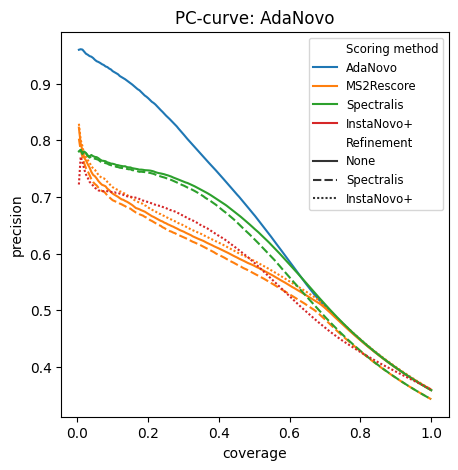

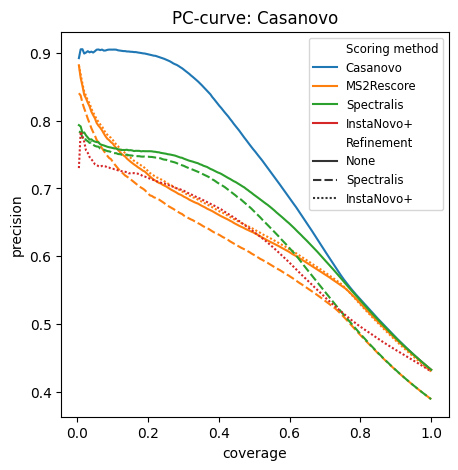

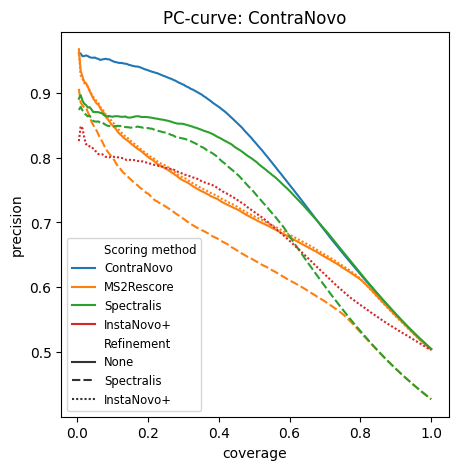

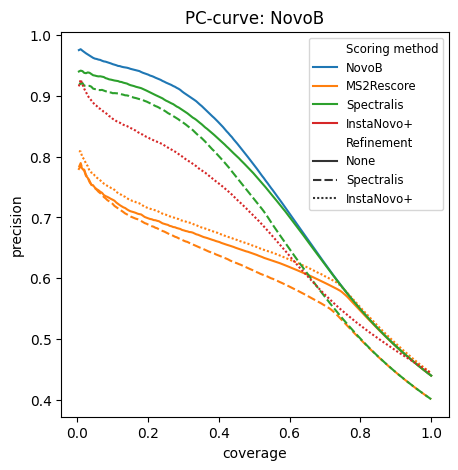

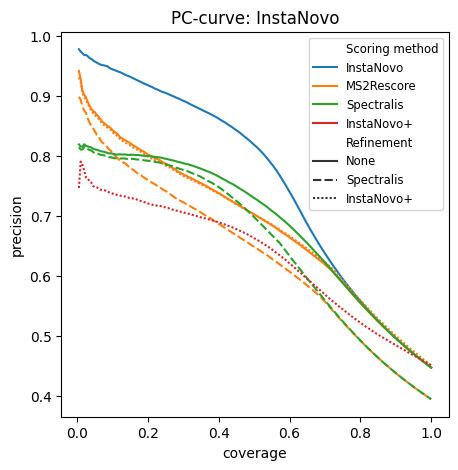

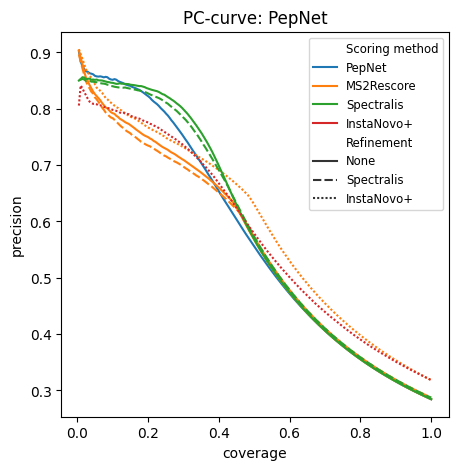

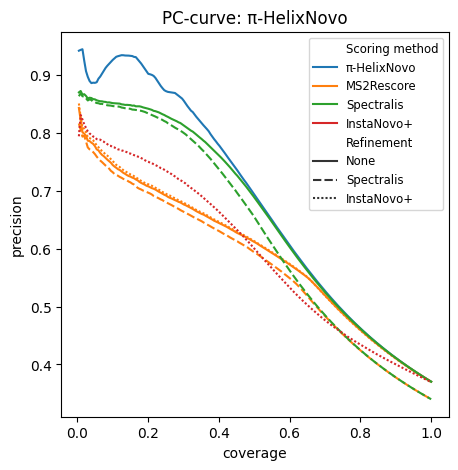

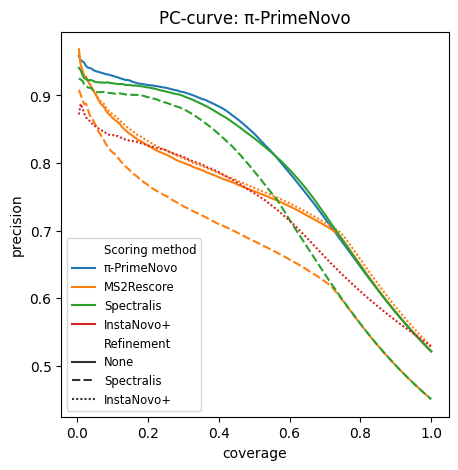

In [32]:
engine_labels = {
    'PepNet': 'PepNet',
    'NovoB': 'NovoB',
    'InstaNovo': 'InstaNovo',
    'Casanovo4.2.0': 'Casanovo',
    'ContraNovo': 'ContraNovo',
    'AdaNovo': 'AdaNovo',
    'pi-PrimeNovo': 'π-PrimeNovo',
    'pi-HelixNovo': 'π-HelixNovo'
}
for engine, score_table in score_tables.items():
    score_table = score_table.copy()
    score_table['Scoring method'] = score_table['Scoring method'].apply(lambda x: x if x not in engine_labels.keys() else engine_labels[engine])
    plt.figure(figsize=(5,5))
    sns.lineplot(
        score_table,
        x='coverage',
        y='precision',
        hue='Scoring method',
        style='Refinement'
    )
    plt.title(f'PC-curve: {engine_labels[engine]}')
    plt.legend(prop={'size': 'small'}) 
    plt.show(f"F3_Rescoring_{engine}")

In [33]:
"""Source data for a multi-panel PC-curve figure (one panel per de novo engine)."""
import numpy as np
import pandas as pd
from string import ascii_uppercase


def pc_panels_source_data(score_tables, engine_labels, figure=None,
                          x="coverage", y="precision",
                          hue="Scoring method", style="Refinement",
                          thin_to=None):
    """Flatten {engine_key: score_table} into one tidy source-data table.

    Panels are lettered A, B, C ... in alphabetical order of the DISPLAY label,
    not of the dict key ('Casanovo4.2.0' would otherwise sort under C but is
    displayed as 'Casanovo').

    thin_to: if given, downsample each drawn line to this many points along x.
    """
    order = sorted(score_tables, key=lambda k: engine_labels.get(k, k))
    if len(order) > len(ascii_uppercase):
        raise ValueError("more panels than letters")

    out, warnings = [], []
    for letter, key in zip(ascii_uppercase, order):
        t = score_tables[key].copy()
        # relabel any engine name in the hue column to its display form
        t[hue] = t[hue].map(lambda v: engine_labels.get(v, v))

        keys = [c for c in (hue, style) if c in t.columns]
        dup = t.duplicated(subset=keys + [x]).sum()
        if dup:
            warnings.append(f"panel {letter} ({engine_labels.get(key,key)}): "
                            f"{dup} duplicate {keys+[x]} rows -> lineplot aggregated these")

        if thin_to:
            # pandas 3 excludes grouping columns from groupby.apply, so select
            # row positions per group and slice instead
            t = t.sort_values(x).reset_index(drop=True)
            take = []
            for _, idx in t.groupby(keys, sort=False).indices.items():
                idx = np.sort(idx)
                pick = np.unique(np.linspace(0, len(idx) - 1,
                                             min(thin_to, len(idx))).astype(int))
                take.append(idx[pick])
            t = t.iloc[np.sort(np.concatenate(take))].reset_index(drop=True)

        t.insert(0, "panel", letter)
        t.insert(1, "engine", engine_labels.get(key, key))
        out.append(t[["panel", "engine"] + keys + [x, y]])

    table = pd.concat(out, ignore_index=True)
    if figure:
        table.insert(0, "figure", figure)
    return table, warnings

table, warnings = pc_panels_source_data(score_tables, engine_labels,
                                        figure="Figure 3", thin_to=300)
for w in warnings:
    print(w)
table.round(5).to_excel("source_data/Source_Data_Figure3.xlsx", sheet_name="Figure 3", index=False)